# Baseline Energy Prediction using Linear Regression

This notebook builds a baseline model to predict energy consumption using historical features.

In [4]:
import pandas as pd
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [7]:
df = pd.read_csv("../data/processed/feature_engineered_data.csv")
df.head()

,timestamp,fridge,ac,lights,microwave,total_power,lag_1,lag_24,rolling_mean_24
0,2023-01-02 00:00:00,83,0,94,0,177,91.0,121.0,404.291667
1,2023-01-02 01:00:00,50,0,62,0,112,177.0,1096.0,363.291667
2,2023-01-02 02:00:00,0,1155,76,0,1231,112.0,43.0,412.791667
3,2023-01-02 03:00:00,0,0,95,0,95,1231.0,1029.0,373.875000
4,2023-01-02 04:00:00,0,0,23,0,23,95.0,2047.0,289.541667


In [8]:
X = df[['lag_1', 'lag_24', 'rolling_mean_24']]
y = df['total_power']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)%temp%

MAE: 661.1206685203304
RMSE: 834.8623204606807


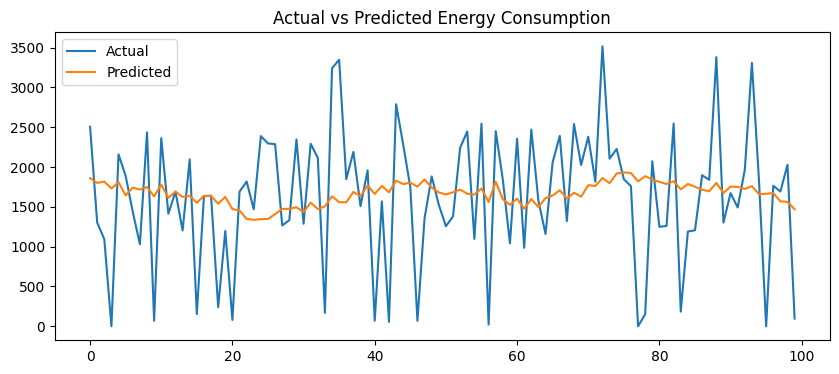

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

## Observation

The Linear Regression model provides a baseline prediction of energy consumption.
The predictions follow the general trend but may not capture complex patterns.
This model will be used for comparison with advanced models like LSTM.